# 1 - Titanic Survival Classifier
### 1. Imports

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

### 2. Load Data

In [3]:

df = pd.read_csv("./dataset/titanic_complete.csv", index_col= 0) # for choosing PassangerId as index
df = df.copy()

# df.info()
print(f"Dataset shape: {df.shape}")
# df.describe()
df.head(10)

Dataset shape: (1309, 11)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S



### 3. Feature Engineering
create new features and clean the other messy oness

In [4]:
# fill missing Ages using median per Pclass and Sex
df['Age'] = df['Age'].fillna(
    df.groupby(['Pclass', 'Sex'])['Age'].transform('median') # filled na of ages based on pclass and sex
)

# Fare NaN
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

# embarked NaN
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # most frequant value

# add family size 
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# check if solo = 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int) # change bool to 0 and 1 

# Cabin NaN replace with unknownn
df['Deck'] = df['Cabin'].str[0].fillna('Unknown')

# extract title for later use 
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# df["Title"].unique()
# remove extra titles so we reduce noise 
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don',
               'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# check
print("Unique Titles:", df['Title'].unique())
print("Unique Decks: ", df['Deck'].unique())


Unique Titles: <StringArray>
['Mr', 'Mrs', 'Miss', 'Master', 'Rare', 'Mme', 'Ms', 'Mlle']
Length: 8, dtype: str
Unique Decks:  <StringArray>
['Unknown', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: str


### 4. Drop cols we don't need

In [5]:
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'FamilySize', 'IsAlone', 'Deck', 'Title'],
      dtype='str')

### 5. Train / Test Split 

In [6]:
# shuffle the data first,
# slice 80% for training and 20% for testing
train_df = df.sample(frac=0.8, random_state=42)

# remove data of train from test df
test_df = df.drop(train_df.index)

X_train = train_df.drop(columns='Survived')
y_train = train_df['Survived']
 
X_test = test_df.drop(columns='Survived')
y_test = test_df['Survived']

#check their size
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 1047 | Test size: 262


### 6. Encode Categorical Columns

In [7]:
X_train = pd.get_dummies(X_train)
X_test  = pd.get_dummies(X_test)

# align----> test gets same columns as train, missing ones filled with 0
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
 
print(f"Feature count after encoding: {X_train.shape[1]}")

Feature count after encoding: 29


### 7. Convert to NumPy Arrays

In [8]:
X_train = X_train.astype(np.float64).values
X_test  = X_test.astype(np.float64).values
 
y_train = y_train.astype(np.float64).values.reshape(-1, 1)
y_test  = y_test.astype(np.float64).values.reshape(-1, 1)

#check type 
print(f"X_train dtype: {X_train.dtype}, shape: {X_train.shape}")
print(f"y_train dtype: {y_train.dtype}, shape: {y_train.shape}")

X_train dtype: float64, shape: (1047, 29)
y_train dtype: float64, shape: (1047, 1)


### Feature Normalization

In [9]:
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0) + 1e-8  # no divide by 0

X_train_scaled = (X_train - mean) / std
X_test_scaled  = (X_test - mean) / std 

In [10]:
print(y_train.mean())  # if this is far from 0.5, you have imbalance

0.38013371537726837


### 8. Logistic Regression

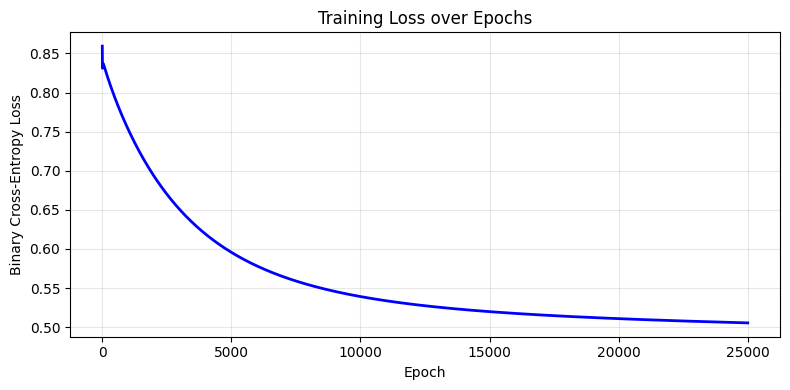

Final training loss: 0.5055


In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))



def compute_loss(y, y_pred, survived_weight = (y_train == 0).sum() / (y_train == 1).sum()): # 62% didnt survive 38% only did so ther is an imbalance
    m = len(y)
    eps = 1e-8
    return -(1/m) * np.sum(
       survived_weight * y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps)
    )

def train_logistic_regression(X, y, alpha=0.01, epochs=1000 , lambda_reg=0.1): # lambda reg for regularization of theta
    m, n = X.shape
    # bias(=1) col to x 
    X_b = np.hstack([np.ones((m, 1)), X])
 
    theta = np.zeros((n + 1, 1))
 
    cost_list = []

    for _ in range(epochs):

        # prediction --> y'
        h = sigmoid(X_b @ theta)

        # loss
        loss = compute_loss(y, h)
        cost_list.append(loss)

        # gradient
        gradient = (1/m) * (X_b.T @ (h - y))
        gradient[1:] += (lambda_reg / m) * theta[1:] # only regulize the theta

        # update
        theta -= alpha * gradient

    return theta, cost_list

# Train the model
theta, cost_list = train_logistic_regression(
    X_train, y_train, alpha=0.001, epochs=25000
)

# Plot training loss curve
plt.figure(figsize=(8, 4))
plt.plot(cost_list, color='b', linewidth=2)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 
print(f"Final training loss: {cost_list[-1]:.4f}")


### 9. Predict & Evaluate

In [12]:
def predict(X, theta, threshold=0.3):
    X_b = np.hstack([np.ones((X.shape[0], 1)), X])
    probs = sigmoid(X_b @ theta)
    return (probs >= threshold).astype(int)

def evaluate(y, y_pred):
    y = y.ravel() # to 1d arr
    y_pred = y_pred.ravel()
 
    TP = np.sum((y_pred == 1) & (y == 1)) # it was positive and we predicted positive
    TN = np.sum((y_pred == 0) & (y == 0)) # it was negative and we predicted correctly
    FP = np.sum((y_pred == 1) & (y == 0)) # it was falsly predicted positive( it was neg)
    FN = np.sum((y_pred == 0) & (y == 1)) # falsely predicted negative(was pos)
 
    accuracy  = (TP + TN) / len(y)
    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
 

    print(f"{'='*40}")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
 
    return {"Accuracy": accuracy, "Precision": precision,
            "Recall": recall, "F1": f1}

y_pred_lr = predict(X_test, theta)
 
# Evaluate
lr_results = evaluate(y_test, y_pred_lr)

  Accuracy  : 0.8435
  Precision : 0.7835
  Recall    : 0.7917
  F1 Score  : 0.7876
